# Phase 2 — Dataset Generation & Exploration

**Goal:** Generate all four manifold datasets, understand their geometry, and build the ground-truth visualisations that later phases will try to recover.

| Dataset | Intrinsic dim | Key challenge |
|---|---|---|
| Swiss Roll | 2D | Curled — needs unrolling |
| S-Curve | 2D | Folded surface |
| Torus | 2D | Topology: can't flatten without tearing |
| Möbius Strip | 2D | Non-orientable, one-sided surface |

**Kernel:** `manifold-discovery`

In [10]:
# Cell 1 — Imports & paths
import sys
from pathlib import Path

# Make src importable from notebooks/
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 — registers 3D projection
import pandas as pd

from src.datasets.generators import load_all_datasets, swiss_roll, s_curve, torus, mobius_strip
from src.utils.plotting import plot_3d, plot_all_3d, savefig
from src.config import CFG

FIGURES = CFG['figures_dir']
SEED    = CFG['random_seed']

print(f'ROOT          : {ROOT}')
print(f'Figures dir   : {FIGURES}')
print(f'Random seed   : {SEED}')

ROOT          : /Users/adi/Desktop/Manifold-discovery
Figures dir   : /Users/adi/Desktop/Manifold-discovery/results/figures
Random seed   : 42


In [11]:
# Cell 2 — Generate all datasets (noise = 0.1)
N_SAMPLES = CFG['n_samples']   # 2000 by default
NOISE     = 0.1

datasets = load_all_datasets(n_samples=N_SAMPLES, noise=NOISE, seed=SEED)

print(f'Generated {len(datasets)} datasets with n_samples={N_SAMPLES}, noise={NOISE}\n')
for name, (X, t) in datasets.items():
    print(f'  {name:<16}  X.shape={X.shape}   t in [{t.min():.3f}, {t.max():.3f}]')

Generated 4 datasets with n_samples=2000, noise=0.1

  Swiss Roll        X.shape=(2000, 3)   t in [4.713, 14.132]
  S-Curve           X.shape=(2000, 3)   t in [-4.709, 4.711]
  Torus             X.shape=(2000, 3)   t in [0.003, 6.283]
  Möbius Strip      X.shape=(2000, 3)   t in [0.007, 6.283]


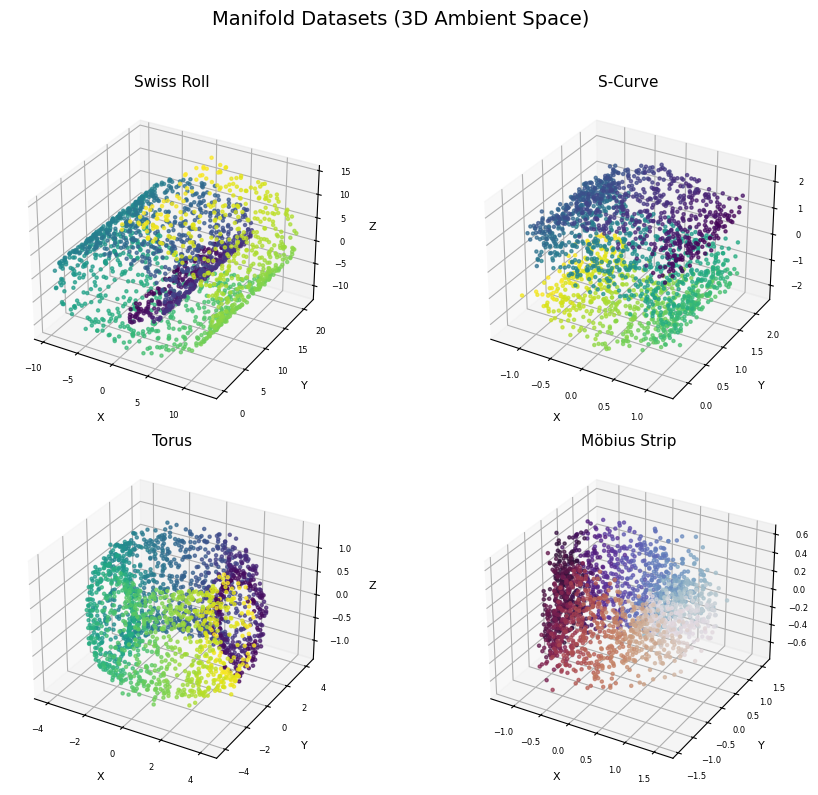

In [12]:
# Cell 3 — 2×2 grid: all four datasets in 3D
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100})

fig = plot_all_3d(datasets, save_path=FIGURES / '01_datasets_3d.png', dpi=150)
plt.show()

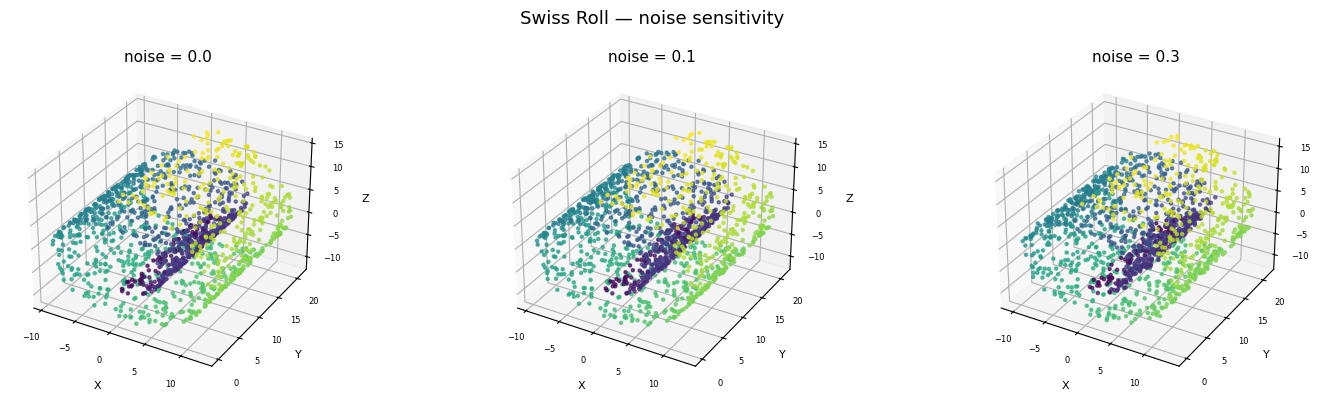

Takeaway: sigma=0.1 is a good default — adds realism without destroying structure.


In [13]:
# Cell 4 — Noise level comparison on the Swiss Roll
# Shows how sigma=0.0 / 0.1 / 0.3 affect point cloud density

noise_levels = CFG['noise_levels']   # [0.0, 0.1, 0.3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': '3d'})
fig.suptitle('Swiss Roll — noise sensitivity', fontsize=13)

for ax, noise in zip(axes, noise_levels):
    X, t = swiss_roll(n_samples=1500, noise=noise, seed=SEED)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap='viridis', s=5, alpha=0.7)
    ax.set_title(f'noise = {noise}', fontsize=11)
    ax.set_xlabel('X', fontsize=8); ax.set_ylabel('Y', fontsize=8); ax.set_zlabel('Z', fontsize=8)
    ax.tick_params(labelsize=6)

plt.tight_layout()
savefig(fig, FIGURES / '01_swiss_roll_noise.png', dpi=150)
plt.show()
print('Takeaway: sigma=0.1 is a good default — adds realism without destroying structure.')

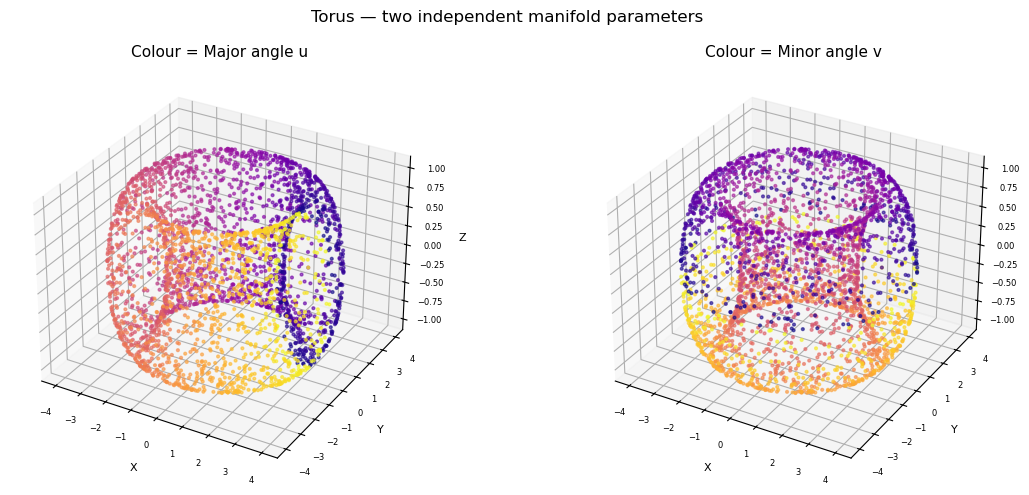

Note: the Torus has TWO periodic parameters (u, v) — both are circular.
A flat 2D embedding must somehow represent two circles — Isomap will tear it.


In [14]:
# Cell 5 — Torus: major vs minor angle
# Colour by major angle (u) and minor angle (v) separately to understand the two parameters

from src.datasets.generators import torus as torus_raw

rng = np.random.default_rng(SEED)
n = 3000
u = rng.uniform(0, 2 * np.pi, n)   # major
v = rng.uniform(0, 2 * np.pi, n)   # minor
R, r = 3.0, 1.0
x = (R + r * np.cos(v)) * np.cos(u)
y = (R + r * np.cos(v)) * np.sin(u)
z = r * np.sin(v)
X_torus = np.column_stack([x, y, z])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
fig.suptitle('Torus — two independent manifold parameters', fontsize=12)

for ax, param, label in zip(axes, [u, v], ['Major angle u', 'Minor angle v']):
    ax.scatter(X_torus[:, 0], X_torus[:, 1], X_torus[:, 2],
               c=param, cmap='plasma', s=4, alpha=0.6)
    ax.set_title(f'Colour = {label}', fontsize=11)
    ax.set_xlabel('X', fontsize=8); ax.set_ylabel('Y', fontsize=8); ax.set_zlabel('Z', fontsize=8)
    ax.tick_params(labelsize=6)

plt.tight_layout()
savefig(fig, FIGURES / '01_torus_angles.png', dpi=150)
plt.show()
print('Note: the Torus has TWO periodic parameters (u, v) — both are circular.')
print('A flat 2D embedding must somehow represent two circles — Isomap will tear it.')

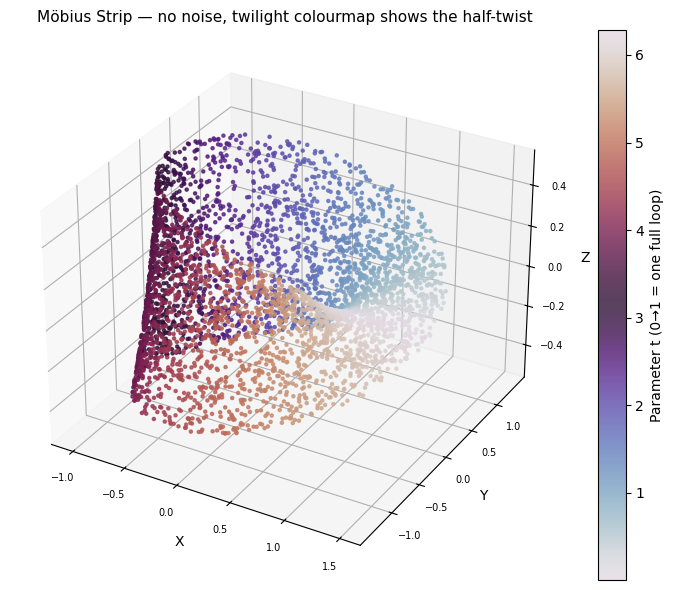

The colour gradient meets itself with a flip at t≈0.5 — that is the half-twist.
This surface has only ONE side: run your finger along it and you cover both faces.


In [15]:
# Cell 6 — Möbius Strip: show the half-twist
# Colour by t to show the non-orientable structure

X_mob, t_mob = mobius_strip(n_samples=4000, noise=0.0, seed=SEED)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(X_mob[:, 0], X_mob[:, 1], X_mob[:, 2],
                 c=t_mob, cmap='twilight', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Parameter t (0→1 = one full loop)')
ax.set_title('Möbius Strip — no noise, twilight colourmap shows the half-twist', fontsize=11)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.tick_params(labelsize=7)
plt.tight_layout()
savefig(fig, FIGURES / '01_mobius.png', dpi=150)
plt.show()
print('The colour gradient meets itself with a flip at t≈0.5 — that is the half-twist.')
print('This surface has only ONE side: run your finger along it and you cover both faces.')

In [16]:
# Cell 7 — Dataset statistics table

rows = []
for name, (X, t) in datasets.items():
    rows.append({
        'Dataset':        name,
        'n_samples':      X.shape[0],
        'Ambient dim':    X.shape[1],
        'Intrinsic dim':  2,
        'X range':        f'[{X.min():.2f}, {X.max():.2f}]',
        't range':        f'[{t.min():.3f}, {t.max():.3f}]',
        'Mean pairwise d': f'{np.mean(np.linalg.norm(X[:200] - X[:200].mean(axis=0), axis=1)):.3f}',
    })

df = pd.DataFrame(rows).set_index('Dataset')
print(df.to_string())

# Save stats CSV
csv_path = ROOT / 'results' / 'metrics' / '01_dataset_stats.csv'
df.to_csv(csv_path)
print(f'\nSaved → {csv_path.relative_to(ROOT)}')

              n_samples  Ambient dim  Intrinsic dim          X range          t range Mean pairwise d
Dataset                                                                                              
Swiss Roll         2000            3              2  [-11.26, 21.04]  [4.713, 14.132]          11.175
S-Curve            2000            3              2    [-2.24, 2.26]  [-4.709, 4.711]           1.588
Torus              2000            3              2    [-4.18, 4.21]   [0.003, 6.283]           3.065
Möbius Strip       2000            3              2    [-1.45, 1.61]   [0.007, 6.283]           1.033

Saved → results/metrics/01_dataset_stats.csv


In [17]:
# Cell 8 — Save datasets to disk as .npz for later phases
import numpy as np

DATA_DIR = CFG['data_dir']

for name, (X, t) in datasets.items():
    fname = name.lower().replace(' ', '_').replace('ö', 'o') + '.npz'
    path  = DATA_DIR / fname
    np.savez_compressed(path, X=X, t=t)
    print(f'  Saved {fname}  ({path.stat().st_size // 1024} KB)')

print('\nAll datasets saved. Load in later notebooks with:')
print("  data = np.load(CFG['data_dir'] / 'swiss_roll.npz')")
print("  X, t = data['X'], data['t']")

  Saved swiss_roll.npz  (59 KB)
  Saved s-curve.npz  (60 KB)
  Saved torus.npz  (60 KB)
  Saved mobius_strip.npz  (60 KB)

All datasets saved. Load in later notebooks with:
  data = np.load(CFG['data_dir'] / 'swiss_roll.npz')
  X, t = data['X'], data['t']


## Phase 2 Summary

| What | Detail |
|---|---|
| Datasets generated | Swiss Roll, S-Curve, Torus, Möbius Strip |
| n_samples | 2000 per dataset |
| Noise | σ = 0.1 (default) |
| Saved to | `data/*.npz` |
| Figures saved | `results/figures/01_*.png` |
| Stats CSV | `results/metrics/01_dataset_stats.csv` |

**Key insights before moving to Phase 3:**
- All four datasets have **intrinsic dimension 2** but live in **ambient dimension 3**.
- The colouring parameter `t` is your **ground truth** — a good method will preserve the gradient.
- The Torus has **two periodic parameters** — flat embeddings must compromise.
- The Möbius Strip is **non-orientable** — some methods will produce mirrored artefacts.
- **σ = 0.1** is the default; use σ = 0.0 for toy examples, σ = 0.3 for robustness tests.

**Next:** `02_pca_isomap.ipynb` — Phase 3, classical baselines.